<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/3_Project/1_EDA_Intro.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Exploratory Data Analysis & Intro

## Goal

1. Investigate top-paying roles and skills in the data science industry.
2. Use Python to explore a real-live dataset on job postings.
3. For job-seekers: use these insights to help find the best job opportunities.

## Final Deliverables:
- Create Jupyter Notebookss (showcasing core skills in Python).
- Create a summary page (via [README.md](README.md)) capturing your findings.
- Share this project via GitHub & LinkedIn.

## Questions to Answer

1. What are the most demanded skills for the top 3 most popular data roles?
2. How are in-demand skills trending for Data Analysts?
3. How well do jobs and skills pay for Data Analysts?
4. What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying)

I'll be focusing on US Data Analyst roles, but you can adapt to any of the following:



## Exploratory Data Analysis for all Data Roles

### Roles to Explore

In [ ]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

// Testing: Start

1. total jobs per country

In [70]:
df_country_counts = df.copy()
df_country_counts = df_country_counts.groupby('job_country').agg(job_count=('job_country', 'count')).sort_values('job_count', ascending=False).reset_index()
df_country_counts

,job_country,job_count
0,United States,206292
1,India,51088
2,United Kingdom,40375
3,France,39922
4,Germany,27694
...,...,...
155,Guinea,4
156,Bhutan,3
157,Lesotho,3
158,Mauritania,3


2. is a given country in the data?

In [ ]:
unique_countries = df['job_country'].unique()
# len(list(unique_countries))
value_to_check = 'Israel'
exists = value_to_check in unique_countries
f"Does {value_to_check} exist? {exists}"

3. Israel positions per job title

In [62]:
il_jobs = df[df['job_country'] == 'Israel'].copy()
il_jobs = il_jobs.groupby('job_title_short').agg(job_count=('job_title_short', 'count')).sort_values('job_count', ascending=False).reset_index()
# il_jobs.loc['Total'] = il_jobs['job_count'].sum() # index damaged
# il_jobs = il_jobs.drop('Total')
il_jobs.loc[len(il_jobs), 'job_title_short'] = 'Total' # index intact
il_jobs.loc[len(il_jobs)-1, 'job_count'] = il_jobs['job_count'].sum()
il_jobs = il_jobs.drop(len(il_jobs)-1)
il_jobs

,job_title_short,job_count
0,Data Analyst,919.0
1,Software Engineer,908.0
2,Data Engineer,801.0
3,Data Scientist,684.0
4,Business Analyst,471.0
5,Senior Data Engineer,288.0
6,Machine Learning Engineer,246.0
7,Senior Data Scientist,235.0
8,Senior Data Analyst,196.0
9,Cloud Engineer,139.0


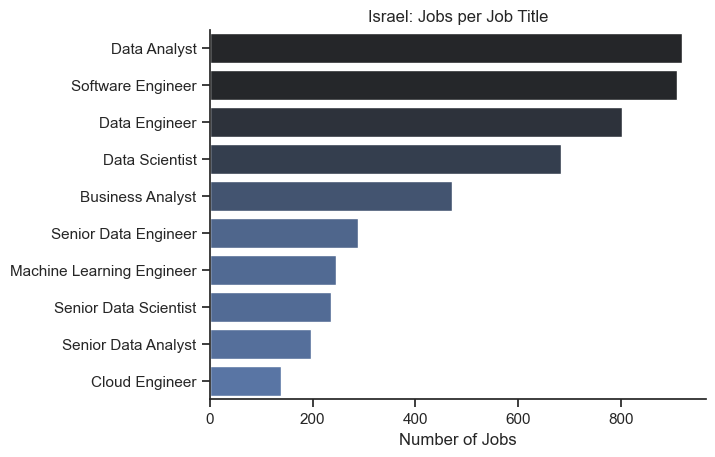

In [68]:
# df_plot = df['job_title_short'].value_counts().to_frame()
# df_plot

il_jobs
sns.set_theme(style='ticks')
sns.barplot(data=il_jobs, x='job_count', y='job_title_short', hue='job_count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Israel: Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

// Testing: End

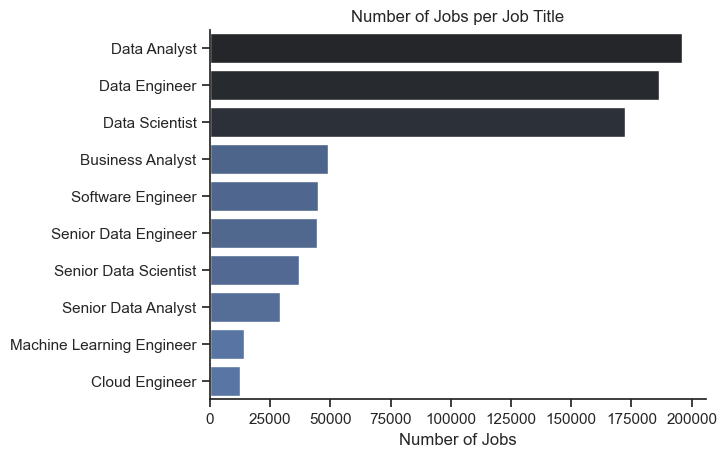

In [69]:
df_plot = df['job_title_short'].value_counts().to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_title_short', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Countries to Explore

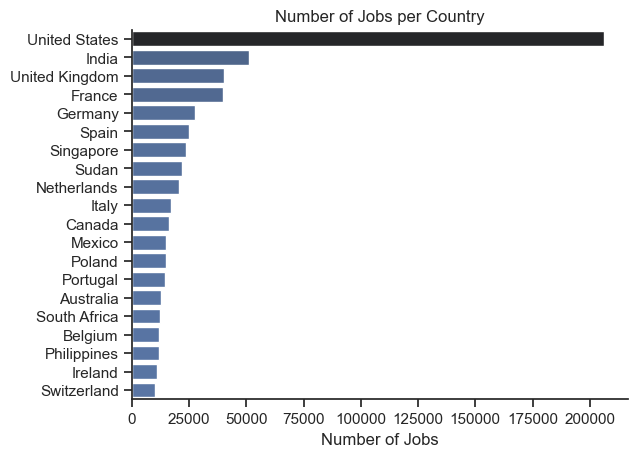

In [71]:
df_plot = df['job_country'].value_counts().to_frame().head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_country', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Country')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Companies to Explore

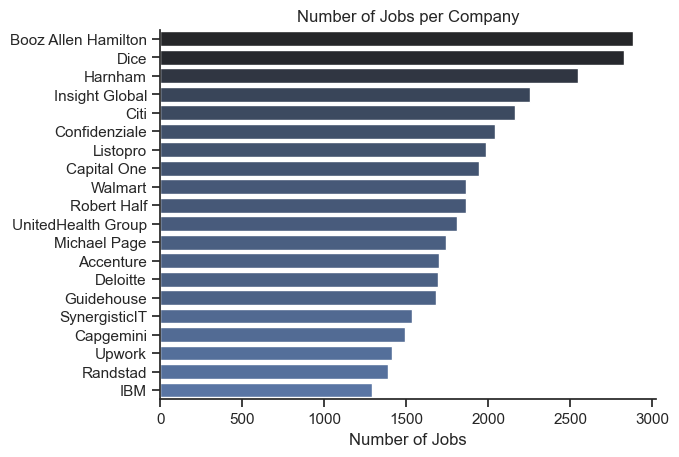

In [78]:
df_plot = df['company_name'].value_counts().to_frame()[1:].head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Company')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Job Opportunities

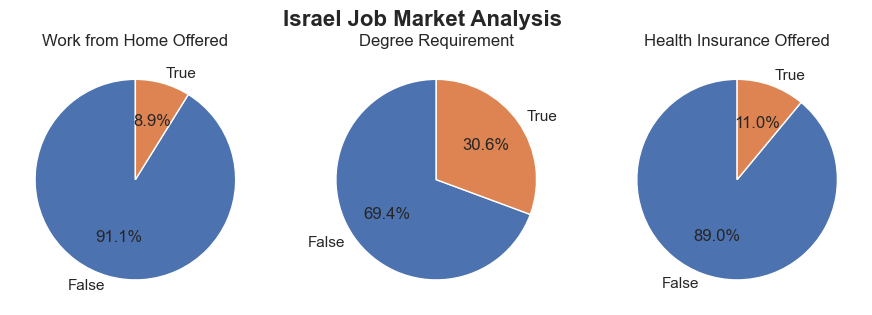

In [106]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
fig.suptitle('Israel Job Market Analysis', fontsize=16, fontweight='bold') # IL data

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

## Exploratory Data Analysis for Data Analysts in the US

In [86]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Filter for US Data Analyst roles

In [87]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

### Locations to Explore:

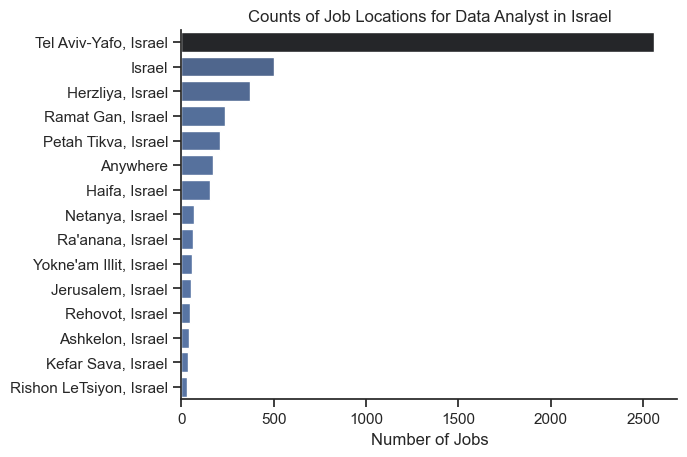

In [103]:
# df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()
df_plot = df[df['job_country'] == 'Israel']['job_location'].value_counts().head(15).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in Israel')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Job Opportunities

// Testing: Start

4. validate IL data

In [108]:
# boolean_fields_il = df[df['job_country'] == 'Israel'][['job_work_from_home','job_no_degree_mention','job_health_insurance']].value_counts()
job_work_from_home = df[df['job_country'] == 'Israel']['job_work_from_home'].value_counts()
job_no_degree_mention = df[df['job_country'] == 'Israel']['job_no_degree_mention'].value_counts()
job_health_insurance = df[df['job_country'] == 'Israel']['job_health_insurance'].value_counts()
job_work_from_home, job_no_degree_mention, job_health_insurance

(job_work_from_home
 False    4715
 True      172
 Name: count, dtype: int64,
 job_no_degree_mention
 False    3401
 True     1486
 Name: count, dtype: int64,
 job_health_insurance
 False    4883
 True        4
 Name: count, dtype: int64)

// Testing: End

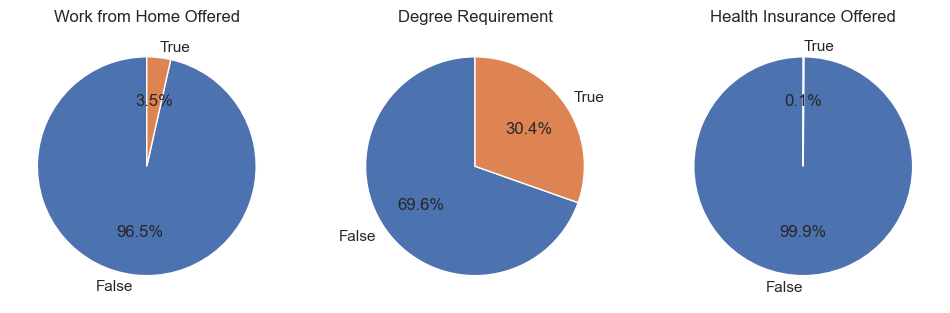

In [109]:
# rewrite the above with a for loop
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    # ax[i].pie(df_DA_US[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].pie(df[df['job_country'] == 'Israel'][column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90) # IL data
    ax[i].set_title(title)

# plt.suptitle('Benefit Analysis of Data Jobs', fontsize=16)
plt.show()

### Companies to Explore:

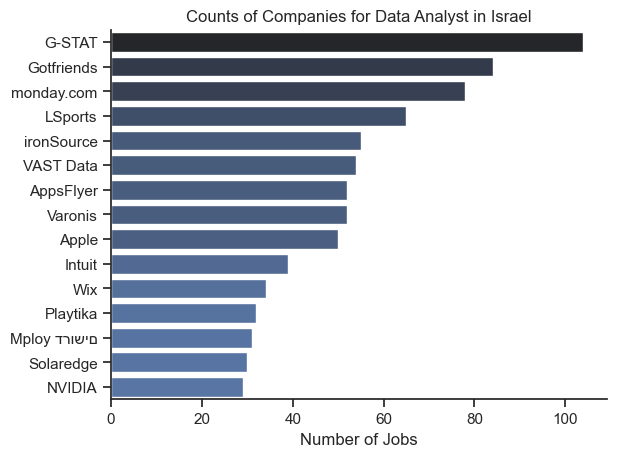

In [110]:
# df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()
df_plot = df[df['job_country'] == 'Israel']['company_name'].value_counts().head(15).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in Israel')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()